#  < 사진 캡션 문장 유사도 측정 >

---

1.   과제 설명 :<br>
사진과 같이 사진 캡션을 여러 가지로 생성할 수도 있다. <br> 이 경우에 어떤 문장을 선택할지를 문장 유사도를 측정하고 이 중에서 가장 유사도가 높은 문장을 선택하면 될 수도 있다.<p>
 ※ 사진 출처 : https://vision.cs.uiuc.edu/pascal-sentences/ <p>
2.   항목 추가 : 이 과제에서는 다음 과정을 거쳐서 처리하고자 한다.
*   wmdistance를 적용해서 word2vec을 활용한 문장 유사도 측정
*   연결 행렬 만들기<br>
     <font size =2, color=grey>(2개씩 문장 유사도가 측정이 되므로 이를 적용해서 어떤 문장이 높은지 판단하는데, 문장과 문장의 측정이므로 A와 B의 관계로 두 개씩 짝지워진 행렬이다.)</font>
*   구글 pagerank 알고리즘을 사용해서 가장 높은 순위를 갖는 아이템


---




0. Word Mover's Distance(WMD) 계산을 지원하기 위해 필요한 라이브러리 설치<br>
<font size="2" color="#6495ED">※ gensim에서 WMD를 계산할 때 Optimal Transport 알고리즘이 필요하며, 이를 지원하는 라이브러리가 pot임</font>

In [1]:
!pip install pot

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.3 MB/s eta 0:00:00


1. WMD 계산에 필요한 패키지 설치<br>
<font size="2" color="#6495ED">※ gensim: Word2Vec, WMD 계산 등 다양한 NLP 작업 지원<br>
※ numpy: 수치 연산 수행<br>
※ IPython.display: 이미지 출력을 위해 사용</font>

In [3]:
!pip install gensim numpy nltk scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 74.3 MB/s eta 0:00:00


In [4]:
import gensim.downloader as api
import numpy as np
import math
from gensim.models import KeyedVectors
from gensim.utils import simple_preprocess
from IPython.display import Image, display

2. Word2Vec 모델 로드<br>
<font size="2" color="#6495ED">※ gensim의 Downloader를 사용해 Google News 데이터로 학습된 사전 학습 Word2Vec 모델을 로드함<br>
※ 이 모델은 단어 벡터를 기반으로 문장 간 유사도를 계산하는 데 사용됨

In [5]:
# Word2Vec 모델 로드

model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


3. 이미지와 캡션 관리<br>
<font size="2" color="#6495ED">※ 이미지 폴더 경로<br>
※ 유사도를 구하고 싶은 이미지와 캡션 데이터 정리하기

In [6]:
# 사진과 사진 캡션 데이터
images_and_captions = {
    "2008_008231.jpg": [
        "(1) A beautiful view in the mountains is taken in by a man wearing shorts.",
        "(2) A man on the summit of a mountain looking at a glider in the sky.",
        "(3) A man stands on a mountain, watching a plane.",
        "(4) A man wearing shorts stands in the snow at the edge of a cliff.",
        "(5) Professor standing on a snowy mountain, watching a plane."
    ],
    "2008_005279.jpg": [
        "(1) A blue and green hummingbird hovers near a pink flower.",
        "(2) A blue hummingbird is flying by a flower.",
        "(3) A hummingbird in front of a flower",
        "(4) A small hummingbird flying near a pink flower.",
        "(5) Colorful hummingbird hovering in front of red flower."
    ],
    "2008_007247.jpg": [
        "(1) A black train engine is facing me on the tracks with its light on in the woods during the day.",
        "(2) A close-up of a black train engine.",
        "(3) A front view of a black train engine on the tracks with people standing on either side.",
        "(4) boy feeding sheep hay",
        "(5) The train is very old and has the number 1225 on it."
    ]
}

4. WMD 기반 유사도 행렬 생성<br>
<font size="2" color="#6495ED">※ 주어진 캡션 리스트와 Word2Vec 모델을 사용해 유사도 행렬 계산하기</font><br>
    - 각 캡션 쌍에 대해 Word Mover's Distance(WMD) 계산<br>
    - WMD 값을 역수로 변환해 유사도를 행렬 형태로 반환<br>
    - 자기 자신과의 유사도는 항상 1로 설정

In [7]:
# WMD 기반 유사도 행렬 생성 함수
def calculate_similarity_matrix(captions, model):
    n = len(captions)  # 캡션 개수
    similarity_matrix = np.zeros((n, n))  # n x n 크기의 유사도 행렬 초기화
    for i in range(n):
        for j in range(n):
            if i == j:
                similarity_matrix[i][j] = 1.0  # 자기 자신과의 유사도는 1
            else:
                # 두 문장 간의 Word Mover's Distance 계산
                distance = model.wmdistance(
                    simple_preprocess(captions[i]),
                    simple_preprocess(captions[j])
                )
                # WMD 값을 역수로 변환해 유사도로 설정
                similarity_matrix[i][j] = 1 / (distance + 1e-5)
    return similarity_matrix

5. Pagerank 알고리즘 적용<br>
<font size="2" color="#6495ED">※ 유사도 행렬을 정규화한 후 Pagerank 알고리즘을 적용하여 가장 중요한 캡션(문장)을 선택함

In [8]:
# Pagerank 알고리즘 적용
def normalize_adjacency_matrix(A):
    n = len(A)  # 행렬 크기 (n x n)
    for j in range(len(A[0])):
        col_sum = sum(A[i][j] for i in range(len(A)))  # 각 열의 합
        if col_sum == 0:  # Dangling 노드 처리
            for i in range(n):
                A[i][j] = 1 / n
        else:
            for i in range(n):
                A[i][j] /= col_sum  # 열 정규화
    return A

def apply_pagerank(A, damping_factor=0.85):
    n = len(A)
    Q = np.ones((n, n)) / n  # 확률 분포 행렬 (n x n, 모든 값이 1/n)
    M = damping_factor * A + (1 - damping_factor) * Q  # Pagerank 행렬 계산

    # 행렬 M의 고유 벡터(steady-state 벡터) 계산
    eigenvalues, eigenvectors = np.linalg.eig(M)
    principal_eigenvector = eigenvectors[:, np.argmax(eigenvalues)]  # 가장 큰 고유값의 고유 벡터
    steady_state = principal_eigenvector / principal_eigenvector.sum()  # 정규화
    return steady_state

6. 각 이미지별 처리<br>
<font size="2" color="#6495ED">※ 각 이미지에 대해 유사도 행렬을 생성하고 Pagerank 알고리즘을 적용하여 캡션을 순위화함

In [12]:
# 이미지 폴더 정의
image_folder = 'image_folder'


사진: 2008_008231.jpg


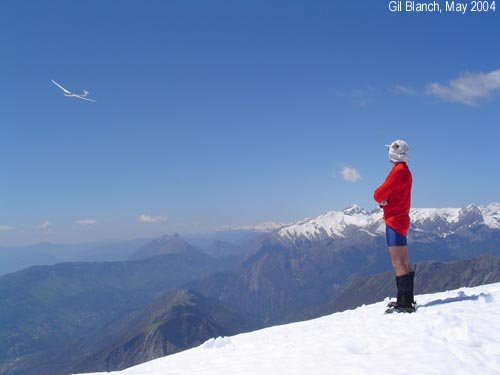

Similarity Matrix:
 [[1.         1.15743418 0.94118082 1.4949443  0.83957485]
 [1.15743418 1.         1.17873797 1.47295975 1.01803318]
 [0.94118082 1.17873797 1.         1.03094302 1.94380747]
 [1.4949443  1.47295975 1.03094302 1.         0.86140555]
 [0.83957485 1.01803318 1.94380747 0.86140555 1.        ]]

Ranked Captions:
Score: 0.209 | Caption: (3) A man stands on a mountain, watching a plane.
Score: 0.203 | Caption: (4) A man wearing shorts stands in the snow at the edge of a cliff.
Score: 0.202 | Caption: (2) A man on the summit of a mountain looking at a glider in the sky.
Score: 0.196 | Caption: (5) Professor standing on a snowy mountain, watching a plane.
Score: 0.190 | Caption: (1) A beautiful view in the mountains is taken in by a man wearing shorts.

사진: 2008_005279.jpg


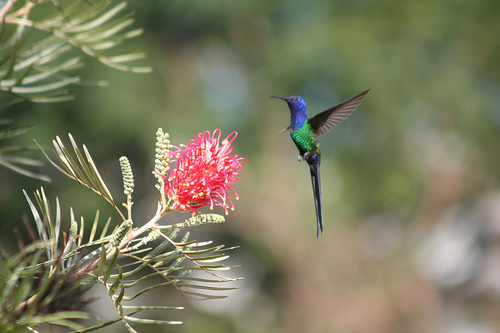

Similarity Matrix:
 [[1.         1.39736718 1.16074628 1.90092046 1.44280197]
 [1.39736718 1.         1.20354471 1.69713494 1.23982495]
 [1.16074628 1.20354471 1.         1.24136023 1.880729  ]
 [1.90092046 1.69713494 1.24136023 1.         1.26794818]
 [1.44280197 1.23982495 1.880729   1.26794818 1.        ]]

Ranked Captions:
Score: 0.208 | Caption: (4) A small hummingbird flying near a pink flower.
Score: 0.203 | Caption: (1) A blue and green hummingbird hovers near a pink flower.
Score: 0.202 | Caption: (5) Colorful hummingbird hovering in front of red flower.
Score: 0.194 | Caption: (2) A blue hummingbird is flying by a flower.
Score: 0.193 | Caption: (3) A hummingbird in front of a flower

사진: 2008_007247.jpg


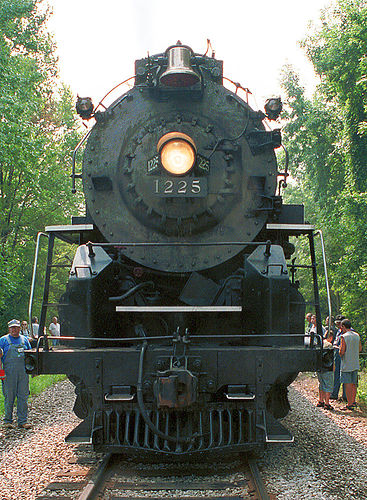

Similarity Matrix:
 [[1.         0.95166447 1.4568452  0.75848253 1.28331671]
 [0.95166447 1.         1.02514676 0.75148733 0.86481142]
 [1.4568452  1.02514676 1.         0.75973363 1.06085385]
 [0.75848253 0.75148733 0.75973363 1.         0.77197738]
 [1.28331671 0.86481142 1.06085385 0.77197738 1.        ]]

Ranked Captions:
Score: 0.220 | Caption: (1) A black train engine is facing me on the tracks with its light on in the woods during the day.
Score: 0.215 | Caption: (3) A front view of a black train engine on the tracks with people standing on either side.
Score: 0.204 | Caption: (5) The train is very old and has the number 1225 on it.
Score: 0.190 | Caption: (2) A close-up of a black train engine.
Score: 0.172 | Caption: (4) boy feeding sheep hay


In [14]:
# 각 이미지별 처리
for image, captions in images_and_captions.items():
    print(f"\n사진: {image}")

    # 1. 이미지 출력
    image_path = f"{image_folder}/{image}"  # 이미지 폴더 경로와 파일 이름 결합
    display(Image(image_path))

    # 2. 유사도 행렬 계산
    similarity_matrix = calculate_similarity_matrix(captions, model)
    print("Similarity Matrix:\n", similarity_matrix)

    # 3. Pagerank 계산
    normalized_matrix = normalize_adjacency_matrix(similarity_matrix)
    pagerank_scores = apply_pagerank(normalized_matrix)

    # 4. 캡션 순위 출력
    ranked_captions = sorted(zip(pagerank_scores, captions), reverse=True)
    print("\nRanked Captions:")
    for score, caption in ranked_captions:
        print(f"Score: {score:.3f} | Caption: {caption}")